# Logical Relationship Issue

This notebook illustrates an issue where a relationship is being identified as 
**Logical** when it should not be. 

Structure set: 'RS.4Field_Logic.BRER.dcm':
             
1. *PTV Cavity* **is Partitioned by** *eval PTV*
2. *eval PTV* **is Partitioned by** - *CTV Cavity*.
3. *PTV Cavity* **Contains** *CTV Cavity*
            
- *PTV Cavity* **Contains** *CTV Cavity*<br> is being treated as **Logical**, 
but this is wrong because it could also be:<br>
    *PTV Cavity* **is Partitioned by** *CTV Cavity*



In [1]:
# Standard Libraries
from pathlib import Path
import re
from pprint import pprint

# Shared Packages
import shapely


# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *

In [2]:
%matplotlib inline

In [3]:
def get_status(structures):
    relation_status = {}
    edges = list(structures.relationship_graph.edges)
    for edge in edges:
        label = f'({edge[0]}, {edge[1]})'
        relation = structures.get_relationship(*edge)
        relation_type = relation.de27im.identify_relation()
        is_logical = relation.is_logical
        relation_status[label] = {
            'Relationship:': relation_type.label,
            'Is Logical:': is_logical
            }
    return relation_status


In [4]:
# Define the path to the test DICOM file
tests_dir = Path.cwd() / r'Tests'
tests_dir = tests_dir.resolve()

In [5]:
test_file_name = 'RS.4Field_Logic.BRER.dcm'

print(f"=== Loading DICOM file ===: {test_file_name}")
dicom_file = DicomStructureFile(
    top_dir=tests_dir,
    file_name=test_file_name
)
print(f"Successfully loaded: {dicom_file}")
print("=== Creating StructureSet from DicomStructureFile ===")
structure_set = StructureSet(dicom_structure_file=dicom_file)
print("\n=== Calculating Structure Relationships ===")


INFO:dicom:Successfully loaded DICOM dataset from RS.4Field_Logic.BRER.dcm


=== Loading DICOM file ===: RS.4Field_Logic.BRER.dcm


INFO:dicom:Extracted 1318 contours from 23 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.4Field_Logic.BRER.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.060 cm/pixel
INFO:structure_set:Building StructureSet from 1318 contour points


Successfully loaded: DICOM RT Structure: BRER for patient 4Field_Logic
=== Creating StructureSet from DicomStructureFile ===


INFO:structure_set:Adding structure BODY (11)
INFO:structure_set:Adding structure CTV Cavity (14)
INFO:structure_set:Adding structure Cavity (15)
INFO:structure_set:Adding structure PTV Cavity (18)
INFO:structure_set:Adding structure PTVn (19)
INFO:structure_set:Adding structure eval PTV (20)
INFO:structure_set:Adding structure Baseline (22)
INFO:structure_set:Adding structure CTVn (25)
INFO:structure_set:Adding structure Heart (28)
INFO:structure_set:Adding structure Lung B (29)
INFO:structure_set:Adding structure Lung L (30)
INFO:structure_set:Adding structure Lung R (31)
INFO:structure_set:Adding structure Matchplane (32)
INFO:structure_set:Adding structure Nodes Axilla I (33)
INFO:structure_set:Adding structure Nodes Axilla II (34)
INFO:structure_set:Adding structure Nodes Axilla III (35)
INFO:structure_set:Adding structure Nodes IMC (36)
INFO:structure_set:Adding structure Nodes SC (37)
INFO:structure_set:Adding structure Scar Wire (39)
INFO:structure_set:Adding structure SpinalCa


=== Calculating Structure Relationships ===


In [6]:
summary = structure_set.summary()
summary.columns
selected_ROI = [14,15,18,20]
summary_index = summary.ROI.isin(selected_ROI)
selected_columns = ['ROI', 'Name', 'DICOM_Type']
summary[summary_index][selected_columns]

,ROI,Name,DICOM_Type
1,14,CTV Cavity,CTV
2,15,Cavity,GTV
3,18,PTV Cavity,PTV
5,20,eval PTV,PTV


In [7]:
relation_status = get_status(structure_set)
struct_pattern = r'\((\d+), (\d+)\)'
selected_relations = {}
for structure_pair_str in relation_status.keys():
    match = re.match(struct_pattern, structure_pair_str)
    if match:
        if (int(match.group(1)) in selected_ROI and
            int(match.group(2)) in selected_ROI):
            selected_relations[structure_pair_str] = relation_status[structure_pair_str]

pprint(selected_relations)

{'(14, 15)': {'Is Logical:': False, 'Relationship:': 'Overlaps with'},
 '(18, 14)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(18, 15)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(18, 20)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(20, 14)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(20, 15)': {'Is Logical:': False, 'Relationship:': 'Overlaps with'}}


1. *PTV Cavity* (18) **is Partitioned by** *eval PTV* (20)
2. *eval PTV* (20) **is Partitioned by** - *CTV Cavity* (14).
3. *PTV Cavity* (18) **Contains** *CTV Cavity* (14)

*PTV Cavity* (18) **Contains** *CTV Cavity* (14)
is being treated as **Logical**, but this is wrong because it could also be:
*PTV Cavity* (18) **is Partitioned by** *CTV Cavity* (14)

#### Conflicting Definitions

In my original definitions, I had:
- A *Is Partitioned by* B and B *is Partitioned by* C.
    > ~~Verify that the relationship A *Contains* C is **Logical**.~~<br>
    > ![Nested partial Partitioned cubes](<../../Images/Logical/Nested partial Partitioned cubes.png>)

But now I am arguing that:
- A *Contains* C is **_Not_ Logical**
because it could also be A *is Partitioned by* C
    > ![Partitioned Boxes](<../../Images/Logical/Nested Partitioned cubes.png>)

#### Partitioned, Partitioned Boxes
![Nested partial Partitioned cubes](<../../Images/Logical/Nested partial Partitioned cubes.png>)

In [8]:
def not_logical_partitioned_contains_example():
    '''cube10 is Partitioned by half_cube10
    half_cube10 is Partitioned by half_cube6

    cube10 Contains half_cube4 is Not Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)
    half_cube6 = make_box(roi_num=3, width=3, length=6,
                     offset_x=1.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = not_logical_partitioned_contains_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)


INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(1, 3)': {'Is Logical:': True, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'}}


**Relationships (1,3) should NOT be _Logical_**

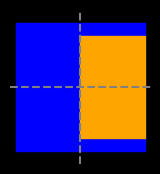

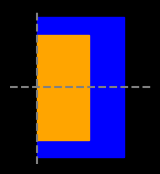

In [9]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Semi-Partitioned Boxes
![Partitioned Boxes](<../../Images/Logical/Nested Partitioned cubes.png>)


In [10]:
def not_logical_partitioned_box_example():
    '''cube10 is Partitioned by half_cube10
    half_cube10 is Partitioned by half_cube6

    cube10 is Partitioned by half_cube6 is Not Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    half_cube6 = make_box(roi_num=3, width=3, length=6,
                     offset_x=3.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = not_logical_partitioned_box_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'}}


**Relationships (1,3) should NOT be _Logical_**

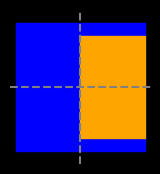

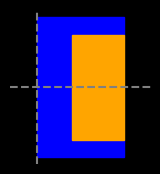

In [11]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Contains, Partitioned Boxes
![Nested partial Partitioned cubes](<../../Images/Logical/Contains,Partitions.png>)

In [12]:
def logical_contains_partitioned_example():
    '''cube10 Contains half_cube10
    half_cube10 is Partitioned by half_cube6

    cube10 Contains half_cube4 is Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=0, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    half_cube6 = make_box(roi_num=3, width=3, length=6, height=6,
                     offset_x=1, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = logical_contains_partitioned_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: is Partitioned by
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'}}


**Relationships (1,3) should be _Logical_**

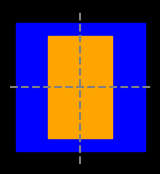

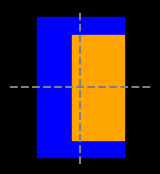

In [13]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)

#### Partitioned, Contains Boxes
![Nested partial Partitioned cubes](<../../Images/Logical/Partitions,Contains.png>)

In [14]:
def logical_partitions_box_example():
    '''cube10 is Partitioned by half_cube10
    half_cube10 Contains half_cube6

    cube10 Contains half_cube4 is Logical
    '''
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    half_cube6 = make_box(roi_num=3, width=3, length=6, height=6,
                     offset_x=2.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + half_cube6
    return slice_data


slice_data = logical_partitions_box_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'is Partitioned by'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationships (1,3) should be _Logical_**

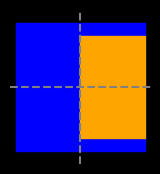

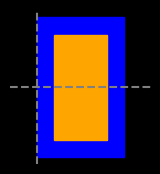

In [15]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
a = plot_ab(poly_a, poly_b)
a = plot_ab(poly_b, poly_c)